In [15]:
import sys
sys.path.append('../src')  # Чтобы импортировать из src/

#noinspection PyUnresolvedReferences
from data_preparation import create_color_gray_pairs
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

In [16]:
test_color_folder = Path('../data/raw')
test_output_folder = Path('../data/processed')
method='luma'

print("Создаем пары цветное → ч/б...")
create_color_gray_pairs(test_color_folder, test_output_folder, method)

Создаем пары цветное → ч/б...

Готово!
Успешно: 3 пар
Не удалось: 0 файлов


In [17]:
color_output_folder = test_output_folder / 'color'
gray_output_folder = test_output_folder / 'gray'

color_files = list(color_output_folder.glob('*.png*'))
gray_files = list(gray_output_folder.glob('*.png*'))

print(f"Создано цветных: {len(color_files)}")
print(f"Создано ч/б: {len(gray_files)}")

# Проверим соответствие имен
color_names = {f.stem for f in color_files}
gray_names = {f.stem for f in gray_files}

if color_names == gray_names:
    print("✓ Все имена файлов совпадают")
else:
    print("✗ Есть несоответствия в именах")

Создано цветных: 3
Создано ч/б: 3
✓ Все имена файлов совпадают


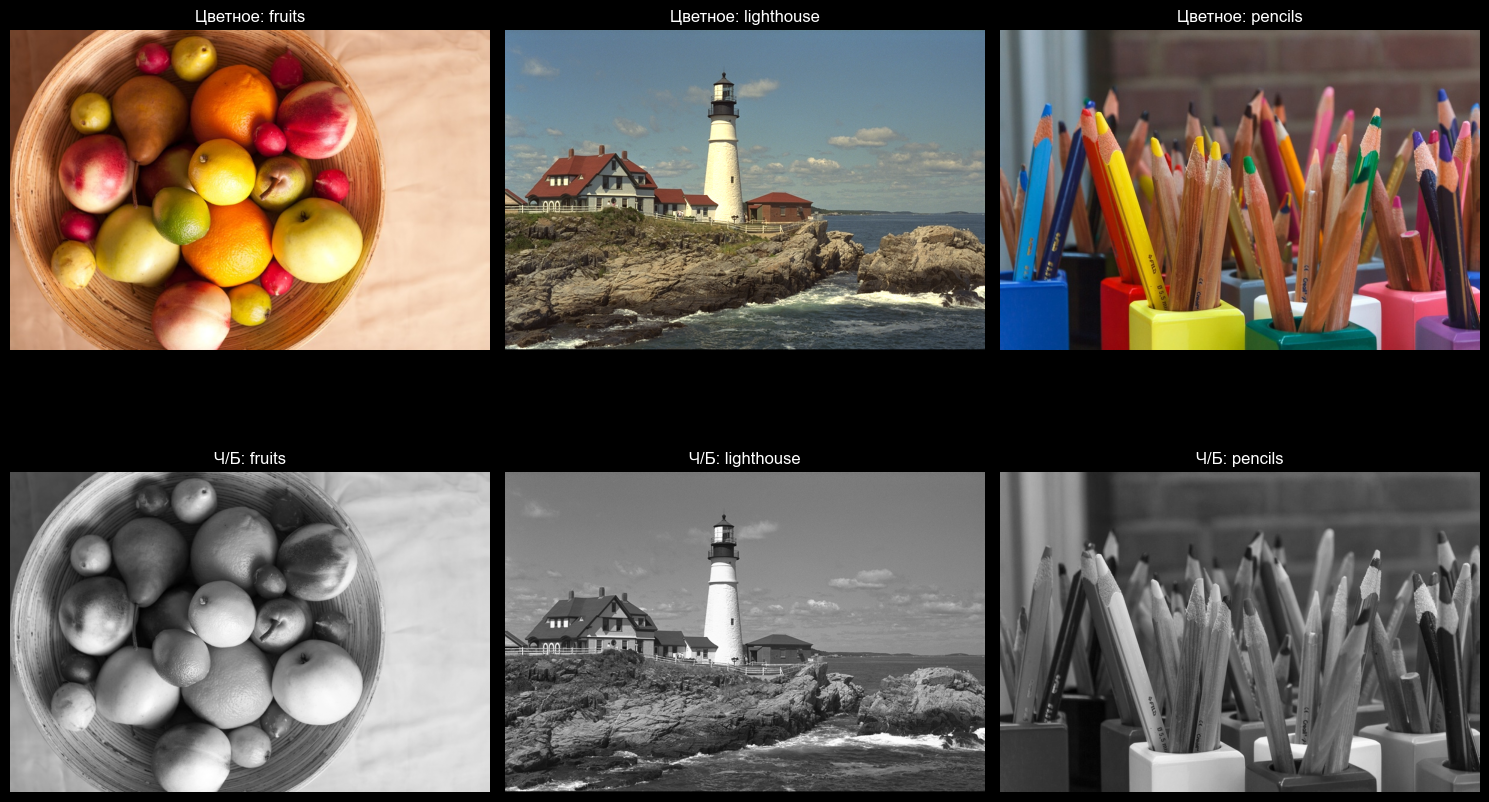

In [18]:
# Визуализация пар (первые 3)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, color_file in enumerate(color_files[:3]):
    # Цветное фото
    color_img = Image.open(color_file)
    axes[0, idx].imshow(color_img)
    axes[0, idx].set_title(f"Цветное: {color_file.stem}")
    axes[0, idx].axis('off')

    # Соответствующее ч/б
    gray_file = gray_output_folder / f"{color_file.stem}.png"
    gray_img = Image.open(gray_file)
    axes[1, idx].imshow(gray_img, cmap='gray')
    axes[1, idx].set_title(f"Ч/Б: {gray_file.stem}")
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

In [19]:
print("\nПроверка размеров:")
for color_file in color_files[:3]:
    color_img = Image.open(color_file)
    gray_file = gray_output_folder / f"{color_file.stem}.png"
    gray_img = Image.open(gray_file)

    print(f"{color_file.stem}: цветное {color_img.size}, ч/б {gray_img.size}",
          "✓" if color_img.size == gray_img.size else "✗")


Проверка размеров:
fruits: цветное (800, 533), ч/б (800, 533) ✓
lighthouse: цветное (768, 512), ч/б (768, 512) ✓
pencils: цветное (800, 533), ч/б (800, 533) ✓


## Результаты создания датасета

1. Успешно созданы парные данные: цветное фото → ч/б версия
2. Имена файлов соответствуют
3. Размеры изображений совпадают
4. Пары готовы для обучения нейросети